In [1]:
#Importing modules
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#check current directory
os.getcwd()

'C:\\Users\\MY COMPUTER\\Documents\\WTF Data Science\\portfolio Projects\\Movie Project'

In [3]:
filename = "movies.txt"
# Search in <search_path>
search_path = "C:\\Users\\MY COMPUTER"

for root, dirs, files in os.walk(search_path):
    if filename in files:
        file_path = os.path.join(root, filename)
        print(f"The path of {filename} is {file_path}")

The path of movies.txt is C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Movie Project\movies.txt


In [4]:
#Read the txt file
file_name = r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Movie Project\movies.txt"
df = pd.read_csv(file_name, sep='\t', header=None)

In [5]:
df

,0,1,2,3,4,5,6
0,1001,Movie 1,Action,9.7,46.4,129,2013
1,1002,Movie 2,Comedy,3,111.8,101,1999
2,1003,Movie 3,NaN,NaN,NaN,113,2015
3,1004,Movie 4,Comedy,6.8,30.87,110,2004
4,1005,Movie 5,Horror,NaN,122.98,110,2008
...,...,...,...,...,...,...,...
996,1997,Movie 997,Horror,8.8,68.93,92,2018
997,1998,Movie 998,Romance,7.5,290.91,108,2011
998,1999,Movie 999,Horror,3.5,NaN,96,2018
999,2000,Movie 1000,Horror,NaN,112.59,132,2018


**Make a copy so we don't alter the raw dataset**

In [6]:
#Make a copy so we don't alter the raw dataset
df1 = df.copy()
df1

,0,1,2,3,4,5,6
0,1001,Movie 1,Action,9.7,46.4,129,2013
1,1002,Movie 2,Comedy,3,111.8,101,1999
2,1003,Movie 3,NaN,NaN,NaN,113,2015
3,1004,Movie 4,Comedy,6.8,30.87,110,2004
4,1005,Movie 5,Horror,NaN,122.98,110,2008
...,...,...,...,...,...,...,...
996,1997,Movie 997,Horror,8.8,68.93,92,2018
997,1998,Movie 998,Romance,7.5,290.91,108,2011
998,1999,Movie 999,Horror,3.5,NaN,96,2018
999,2000,Movie 1000,Horror,NaN,112.59,132,2018


In [7]:
#check info of data
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1001 non-null   object
 1   1       1001 non-null   object
 2   2       951 non-null    object
 3   3       901 non-null    object
 4   4       881 non-null    object
 5   5       1001 non-null   object
 6   6       1001 non-null   object
dtypes: object(7)
memory usage: 54.9+ KB


In [8]:
#Get the last row of the data
last_row = df1.iloc[-1]
table_header = last_row
table_header

0            Movie_ID
1               Title
2               Genre
3              Rating
4    Revenue_Millions
5    Duration_Minutes
6                Year
Name: 1000, dtype: object

In [9]:
#Reassign the table header
df1.columns = ["Movie_ID","Title","Genre","Rating","Revenue_Millions","Duration_Minutes", "Year"]
df1

,Movie_ID,Title,Genre,Rating,Revenue_Millions,Duration_Minutes,Year
0,1001,Movie 1,Action,9.7,46.4,129,2013
1,1002,Movie 2,Comedy,3,111.8,101,1999
2,1003,Movie 3,NaN,NaN,NaN,113,2015
3,1004,Movie 4,Comedy,6.8,30.87,110,2004
4,1005,Movie 5,Horror,NaN,122.98,110,2008
...,...,...,...,...,...,...,...
996,1997,Movie 997,Horror,8.8,68.93,92,2018
997,1998,Movie 998,Romance,7.5,290.91,108,2011
998,1999,Movie 999,Horror,3.5,NaN,96,2018
999,2000,Movie 1000,Horror,NaN,112.59,132,2018


In [10]:
#Drop the last row
df1 =df1.drop(df1.index[-1])
df1

,Movie_ID,Title,Genre,Rating,Revenue_Millions,Duration_Minutes,Year
0,1001,Movie 1,Action,9.7,46.4,129,2013
1,1002,Movie 2,Comedy,3,111.8,101,1999
2,1003,Movie 3,NaN,NaN,NaN,113,2015
3,1004,Movie 4,Comedy,6.8,30.87,110,2004
4,1005,Movie 5,Horror,NaN,122.98,110,2008
...,...,...,...,...,...,...,...
995,1996,Movie 996,Sci-Fi,NaN,NaN,108,2017
996,1997,Movie 997,Horror,8.8,68.93,92,2018
997,1998,Movie 998,Romance,7.5,290.91,108,2011
998,1999,Movie 999,Horror,3.5,NaN,96,2018


In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Movie_ID          1000 non-null   object
 1   Title             1000 non-null   object
 2   Genre             950 non-null    object
 3   Rating            900 non-null    object
 4   Revenue_Millions  880 non-null    object
 5   Duration_Minutes  1000 non-null   object
 6   Year              1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


In [12]:
#Standardizing the datatypes
df1["Rating"] = df1["Rating"].astype(float)
df1["Revenue_Millions"] = df1["Revenue_Millions"] .astype(float)
df1["Duration_Minutes"] = df1["Duration_Minutes"] .astype(float)

**Making another copy**

In [13]:
df2 = df1.copy()

In [14]:
#Making Unique Identifier the index
df2 = df2.set_index('Movie_ID')
df2.head(20)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes,Year
Movie_ID,,,,,,
1001,Movie 1,Action,9.7,46.40,129.0,2013
1002,Movie 2,Comedy,3.0,111.80,101.0,1999
1003,Movie 3,NaN,NaN,NaN,113.0,2015
1004,Movie 4,Comedy,6.8,30.87,110.0,2004
1005,Movie 5,Horror,NaN,122.98,110.0,2008
1006,Movie 6,Action,1.9,60.73,127.0,2020
1007,Movie 7,Comedy,1.6,79.66,93.0,2017
1008,Movie 8,Sci-Fi,4.7,88.21,129.0,2004
1009,Movie 9,Action,1.4,234.42,88.0,1996


In [15]:
#Drop Year column
df2 = df2.drop(columns=['Year'])
df2.head(20)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1003,Movie 3,NaN,NaN,NaN,113.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1005,Movie 5,Horror,NaN,122.98,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
1008,Movie 8,Sci-Fi,4.7,88.21,129.0
1009,Movie 9,Action,1.4,234.42,88.0


In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 1001 to 2000
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Title             1000 non-null   object 
 1   Genre             950 non-null    object 
 2   Rating            900 non-null    float64
 3   Revenue_Millions  880 non-null    float64
 4   Duration_Minutes  1000 non-null   float64
dtypes: float64(3), object(2)
memory usage: 46.9+ KB


In [17]:
#Drop rows with no rating
df2= df2.dropna(subset=['Rating'])
df2.head(20)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
1008,Movie 8,Sci-Fi,4.7,88.21,129.0
1009,Movie 9,Action,1.4,234.42,88.0
1011,Movie 11,Romance,7.7,164.90,135.0
1013,Movie 13,Drama,7.9,10.36,83.0


In [18]:
#Counting null values
print(df1['Rating'].isnull().sum())
print(df2['Rating'].isnull().sum())

100
0


In [19]:
print(df2['Genre'].isnull().sum())

46


In [20]:
#Set Blank Genre to Unknown
df2['Genre'] = df2['Genre'].fillna('Unknown')
df2.head(20)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
1008,Movie 8,Sci-Fi,4.7,88.21,129.0
1009,Movie 9,Action,1.4,234.42,88.0
1011,Movie 11,Romance,7.7,164.90,135.0
1013,Movie 13,Drama,7.9,10.36,83.0


In [21]:
print(df2['Genre'].isnull().sum())
print(df2['Revenue_Millions'].isnull().sum())

0
104


In [22]:
#One-Way
Describes = df2.groupby('Genre')['Revenue_Millions'].agg(["mean", "median", "min", "max"])
Describes

,mean,median,min,max
Genre,,,,
Action,149.271019,70.220,6.26,3278.07
Comedy,117.074750,71.240,4.25,849.92
Drama,133.191111,78.240,4.71,802.04
Horror,144.690990,87.520,9.55,1312.36
Romance,117.963153,68.610,2.76,1215.44
Sci-Fi,111.945800,70.975,3.02,778.66
Unknown,80.553500,65.140,3.82,279.74


In [23]:
#Option 2 - which I prefer, cos it gives me an entire overview of the data
Describe = df2.groupby('Genre')['Revenue_Millions'].describe()
Describe

,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Action,216.0,149.271019,266.856725,6.26,39.3250,70.220,163.5850,3278.07
Comedy,120.0,117.074750,131.793758,4.25,33.5975,71.240,153.9925,849.92
Drama,108.0,133.191111,152.244181,4.71,37.6925,78.240,163.6175,802.04
Horror,101.0,144.690990,184.465504,9.55,36.0500,87.520,168.9400,1312.36
Romance,111.0,117.963153,152.458258,2.76,36.3650,68.610,131.5750,1215.44
Sci-Fi,100.0,111.945800,143.555281,3.02,34.3600,70.975,124.5100,778.66
Unknown,40.0,80.553500,58.658069,3.82,33.4325,65.140,108.4475,279.74


In [24]:
df2["Revenue_Millions"].astype(float).describe()

count     796.000000
mean      129.146445
std       188.542040
min         2.760000
25%        36.127500
50%        71.500000
75%       148.035000
max      3278.070000
Name: Revenue_Millions, dtype: float64

In [25]:
#Using this to keep track of the null values in the revenue column
# This calculates total nulls in the entire column
total_nulls = df2['Revenue_Millions'].isnull().sum()
print(f"Total null values: {total_nulls}")

# This calculates nulls by genre
nulls_by_genre = df2.groupby('Genre')['Revenue_Millions'].apply(lambda x: x.isnull().sum())
print(nulls_by_genre)

Total null values: 104
Genre
Action     33
Comedy     10
Drama      12
Horror     18
Romance    12
Sci-Fi     13
Unknown     6
Name: Revenue_Millions, dtype: int64


In [26]:
#THIS REPLACES NAN REVENUE VALUES FOR HORROR, DRAMA, AND SCI-FI MOVIES WITH THEIR RESPECTIVE MEDIAN(IE 50%)(THIS DOES SO SEPERATELY USING NP.WHERE)

condition_1 = (df2['Genre'] == "Horror")

df2['Revenue_Millions']  = np.where(
    condition_1 & df2['Revenue_Millions'].isnull(),  # Check if condition is true AND value is NaN
    Describe['50%'].loc['Horror'],                      # Value to use if condition is met
    df2['Revenue_Millions'])                            #keeps original value


condition_2 = (df2['Genre'] == "Drama")

df2['Revenue_Millions']  = np.where(
    condition_2 & df2['Revenue_Millions'].isnull(),  # Check if condition is true AND value is NaN
    Describe['50%'].loc['Drama'],                      # Value to use if condition is met
    df2['Revenue_Millions'])                           #keeps original value


condition_1 = (df2['Genre'] == "Sci-Fi")

df2['Revenue_Millions']  = np.where(
    condition_1 & df2['Revenue_Millions'].isnull(),  # Check if condition is true AND value is NaN
    Describe['50%'].loc['Sci-Fi'],                      # Value to use if condition is met
    df2['Revenue_Millions'])                             #keeps original value


df2.head(30)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
1008,Movie 8,Sci-Fi,4.7,88.21,129.0
1009,Movie 9,Action,1.4,234.42,88.0
1011,Movie 11,Romance,7.7,164.90,135.0
1013,Movie 13,Drama,7.9,10.36,83.0


In [29]:
#VERSION 2 OF THE ABOVE, TRYING TO BE MORE EFFICIENT

Median_Horror = Describe['50%'].loc['Horror'].item()
Median_Drama = Describe['50%'].loc['Drama'].item()
Median_Sci_fi = Describe['50%'].loc['Sci-Fi'].item()

conditions = [(df2["Genre"] == "Horror")& (df2['Revenue_Millions'].isnull()),
              (df2["Genre"] == "Drama")& (df2['Revenue_Millions'].isnull()),
              (df2["Genre"] == "Sci-Fi")& (df2['Revenue_Millions'].isnull())]

values = [Median_Horror, Median_Drama, Median_Sci_fi]

df2['Revenue_Millions'] = np.select(conditions, values, default = df2['Revenue_Millions'])
df2.head(30)

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
1008,Movie 8,Sci-Fi,4.7,88.21,129.0
1009,Movie 9,Action,1.4,234.42,88.0
1011,Movie 11,Romance,7.7,164.90,135.0
1013,Movie 13,Drama,7.9,10.36,83.0


In [27]:
#Using this to keep track of the null values in the revenue column
# This calculates total nulls in the entire column
total_nulls = df2['Revenue_Millions'].isnull().sum()
print(f"Total null values: {total_nulls}")

# This calculates nulls by genre - CORRECTED
nulls_by_genre = df2.groupby('Genre')['Revenue_Millions'].apply(lambda x: x.isnull().sum())
print(nulls_by_genre)

Total null values: 61
Genre
Action     33
Comedy     10
Drama       0
Horror      0
Romance    12
Sci-Fi      0
Unknown     6
Name: Revenue_Millions, dtype: int64


In [28]:
df2

,Title,Genre,Rating,Revenue_Millions,Duration_Minutes
Movie_ID,,,,,
1001,Movie 1,Action,9.7,46.40,129.0
1002,Movie 2,Comedy,3.0,111.80,101.0
1004,Movie 4,Comedy,6.8,30.87,110.0
1006,Movie 6,Action,1.9,60.73,127.0
1007,Movie 7,Comedy,1.6,79.66,93.0
...,...,...,...,...,...
1994,Movie 994,Romance,7.8,23.98,93.0
1995,Movie 995,Comedy,9.1,32.84,137.0
1997,Movie 997,Horror,8.8,68.93,92.0


In [29]:
#Highly Rated action movies
Action = df2[df2['Genre'] == 'Action']
High_Rate_Action_Movies = Action.groupby('Title')['Rating'].mean().sort_values(ascending=False)
High_Rate_Action_Movies.head(20)

Title
Movie 918    10.0
Movie 382     9.9
Movie 295     9.9
Movie 623     9.9
Movie 274     9.8
Movie 570     9.8
Movie 820     9.8
Movie 154     9.8
Movie 125     9.7
Movie 251     9.7
Movie 520     9.7
Movie 445     9.7
Movie 729     9.7
Movie 1       9.7
Movie 573     9.6
Movie 958     9.6
Movie 555     9.6
Movie 322     9.5
Movie 354     9.4
Movie 530     9.4
Name: Rating, dtype: float64

In [30]:
#Here we use .groupby and .agg to define the aggregations and on what columns the data for thr aggregations come from.

Final_Data_Report = df2.groupby('Genre').agg(
    Average_Rating=('Rating', 'mean'),
    Average_Duration=('Duration_Minutes', 'mean'),
    Average_Revenue=('Revenue_Millions', 'mean'),
    Max_Revenue=('Revenue_Millions', 'max'),
    Min_Revenue=('Revenue_Millions', 'min'),
    Duration_Standard_Deviation=('Duration_Minutes', 'std')  
 ).round(2)
Final_Data_Report

,Average_Rating,Average_Duration,Average_Revenue,Max_Revenue,Min_Revenue,Duration_Standard_Deviation
Genre,,,,,,
Action,5.53,102.52,149.27,3278.07,6.26,20.27
Comedy,5.68,106.15,117.07,849.92,4.25,20.38
Drama,5.65,105.75,127.70,802.04,4.71,19.92
Horror,5.34,107.92,136.04,1312.36,9.55,18.57
Romance,5.69,105.40,117.96,1215.44,2.76,18.68
Sci-Fi,5.46,104.06,107.23,778.66,3.02,21.01
Unknown,5.20,110.54,80.55,279.74,3.82,17.39


In [31]:
Final_Data_Report.to_csv(r"C:\Users\MY COMPUTER\Documents\WTF Data Science\portfolio Projects\Movie Project\Final_Movie_Report.csv")

***VISUALIZATION***

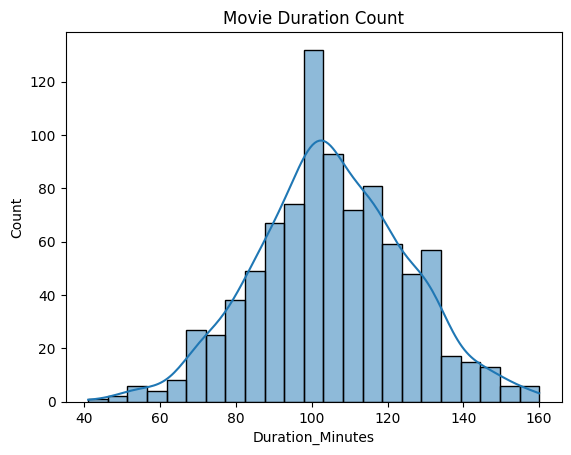

In [32]:
#Visualizing movie Duration count
sns.histplot(data=df2, x='Duration_Minutes',  kde=True)
plt.title("Movie Duration Count")
plt.savefig('Fig1')
plt.show();

In [33]:
#To answer the question: If 90 minutes is standard
print(df2['Duration_Minutes'].value_counts().head(10))
print(f'mean:{df2['Duration_Minutes'].mean()}')
print(f"median:{df2['Duration_Minutes'].median()}")

Duration_Minutes
103.0    26
102.0    24
99.0     24
105.0    22
107.0    21
98.0     21
101.0    21
104.0    20
117.0    20
114.0    20
Name: count, dtype: int64
mean:105.18777777777778
median:104.0


<b>So for the above, It is obvious that 90 minutes is definitely not standard. A duration of a little above 100 minutes is more standard</b>

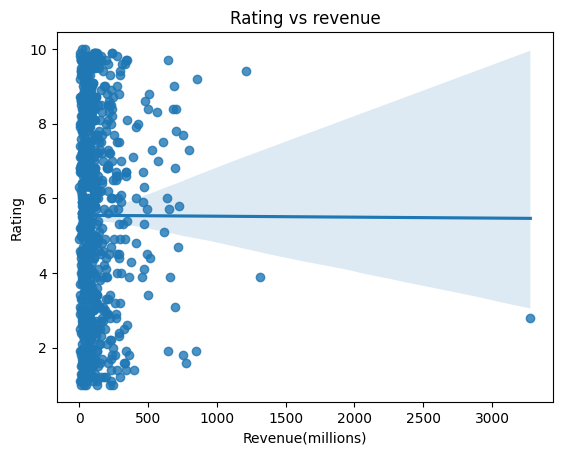

In [34]:
#Rating vs Revenue with a best fit Line
sns.regplot(data=df2, x='Revenue_Millions', y='Rating')
plt.ylabel('Rating')
plt.xlabel('Revenue(millions)')
plt.title("Rating vs revenue")
plt.savefig('Fig2')
plt.show()

In [37]:
#calculating top 5 genres
top5_genres = Final_Data_Report.sort_values(by='Average_Duration', ascending=False).tail(5)
top5_genres = top5_genres['Average_Duration']
top5_genres

Genre
Comedy     106.15
Drama      105.75
Romance    105.40
Sci-Fi     104.06
Action     102.52
Name: Average_Duration, dtype: float64

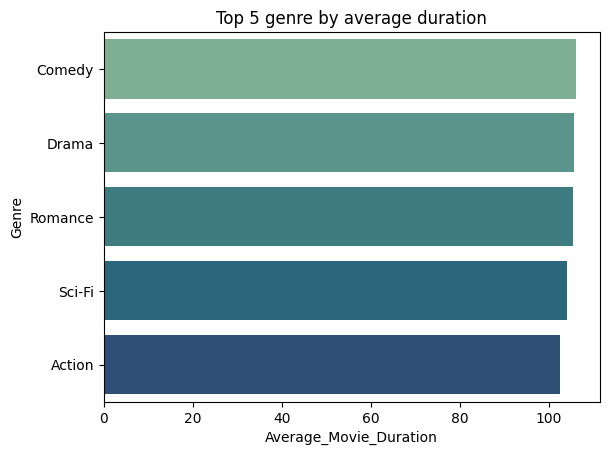

In [38]:
#Top 5 genre by average duration
sns.barplot(
    x=top5_genres.values, 
    y=top5_genres.index, 
    hue=top5_genres.index, 
    palette='crest', 
    legend=False )
# sns.barplot(x=top5_genres.values, y=top5_genres.index, palette='crest')
plt.xlabel("Average_Movie_Duration")
plt.ylabel("Genre")
plt.title("Top 5 genre by average duration")
plt.savefig('Fig3');

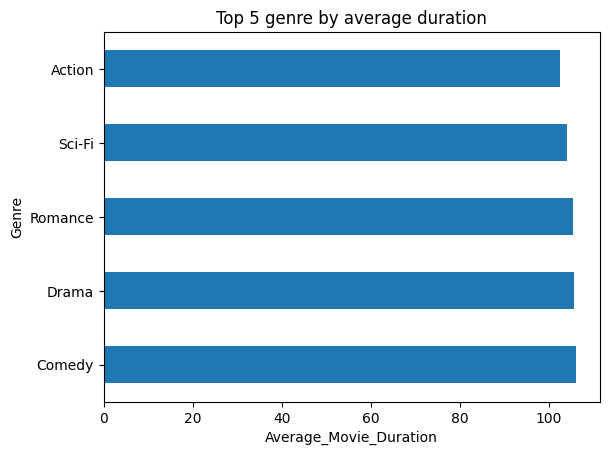

In [39]:
#Using direct Pandas Visualization
top5_genres.plot(kind="barh")
plt.xlabel("Average_Movie_Duration")
plt.ylabel("Genre")
plt.title("Top 5 genre by average duration");

In [40]:
Sum_revenue = df2.groupby("Genre")["Revenue_Millions"].sum()
Sum_revenue

Genre
Action     32242.540
Comedy     14048.970
Drama      15323.520
Horror     16189.150
Romance    13093.910
Sci-Fi     12117.255
Unknown     3222.140
Name: Revenue_Millions, dtype: float64

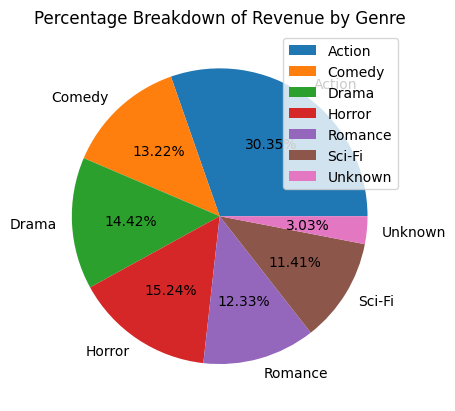

In [41]:
#Percentage Breakdown of Revenue by Genre
plt.pie(
    Sum_revenue,
    labels = Sum_revenue.index,
    autopct = '%1.2f%%',
    # colors = ["pink", "purple", "blue", "orange", "yellow"]
)
plt.legend()
plt.title("Percentage Breakdown of Revenue by Genre")
plt.show()

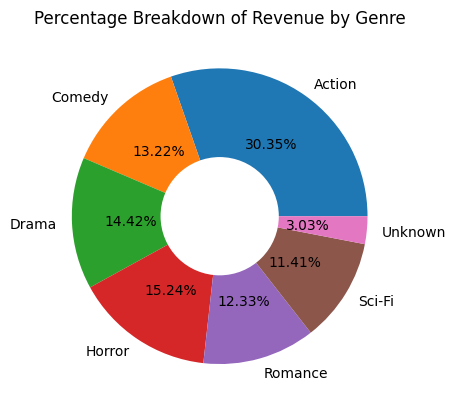

''

In [42]:
#Percentage Breakdown of Revenue by Genre
#Making it a Donut
plt.pie(
    Sum_revenue,
    labels = Sum_revenue.index,
    autopct = '%1.2f%%',
    # colors = ["pink", "purple", "blue", "orange", "yellow"]
)
centre_circle = plt.Circle((0,0), 0.40, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# plt.legend(loc='lower right')
plt.title("Percentage Breakdown of Revenue by Genre")
plt.savefig('Fig4')
plt.show()
;

In [165]:
from matplotlib.backends.backend_pdf import PdfPages

In [166]:
filename = 'multipage_plots.pdf'

figure_files = ["Fig1.png", "Fig2.png", "Fig3.png", "Fig4.png"]
with PdfPages(filename) as pdf:
    for file in figure_files:
        fig = plt.figure()
        img = plt.imread(file)
        plt.imshow(img)
        plt.axis('off')
        pdf.savefig() # Saves the current figure to a new PDF page
        plt.close()